# M6 — Готовка на кухні 🍳

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.

Кухня — єдина кімната з вологістю, яка помітно й швидко реагує на побутову
активність: варіння, смаження, чайник, миття посуду гарячою водою. Цей
модуль шукає моменти, коли вологість різко піднімається, і перевіряє, що
причина локальна (кухня), а не спільна (волога погода на вулиці).

## Питання

> **Коли на кухні готували і наскільки насправді зростає вологість?**

Підпитання:
1. Який поріг приросту вологості відділяє «готували» від шуму датчика?
2. Скільки таких подій на тиждень, які вони за тривалістю й силою?
3. Чи це справді кухня (локальний стрибок), а не волога погода (росте всюди)?
4. Коли частіше готують — о котрій годині, у які дні тижня?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import cooking, cleaning

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12})
pd.set_option("display.width", 200)

out = cooking.run_all(ROOT)         # уся детекція живе у src/cooking.py
minute, wide = out["minute"], out["wide"]
tuning = out["tuning"]
d_ev, h_ev = out["detailed_events"], out["hourly_events"]
events, metrics = out["events"], out["metrics"]
KYIV = cooking.KYIV
print("готово")

готово


## Дані

Два незалежні джерела, як і в решті проєкту:

| Джерело | Детальність | Глибина | Навіщо тут |
|---|---|---|---|
| `readings_detailed.csv` | ~10–20 с → ресемпл до 1 хв | 10 днів | точна форма події: пік, тривалість, повернення до норми |
| `hours_wide.csv` | 1 година | 6 місяців | довгостроковий ритм: скільки подій на тиждень, коли частіше |

Кухонна вологість (`kitchen_hum`) має покриття лише **68 %** у погодинній таблиці —
датчик місяць мовчав улітку (див. M1). У 10-денному детальному вікні дірок немає.
Для порівняння «локально це чи погода» використовуємо вологість спальні (`bedroom_hum`)
у ті самі хвилини.

In [2]:
src_tbl = pd.DataFrame([
    {"джерело": "readings_detailed.csv (1 хв)", "рядків": len(minute),
     "від": str(minute.index.min())[:16], "до": str(minute.index.max())[:16],
     "пропусків kitchen_hum": int(minute.kitchen_hum.isna().sum())},
    {"джерело": "hours_wide.csv (1 год)", "рядків": len(wide),
     "від": str(wide.ts.min())[:16], "до": str(wide.ts.max())[:16],
     "пропусків kitchen_hum": int(wide.kitchen_hum.isna().sum())},
])
src_tbl

,джерело,рядків,від,до,пропусків kitchen_hum
0,readings_detailed.csv (1 хв),14401,2026-09-05 18:27,2026-09-15 18:27,0
1,hours_wide.csv (1 год),4402,2026-03-16 08:00,2026-09-15 17:00,1723


## 1. Поріг на детальних даних (10 днів)

Метод: ресемплимо кухонну вологість до 1 хв. База — ковзна медіана
**попередньої години** (`closed="left"`, поточна хвилина в базу не входить).
Подія стартує, коли приріст над базою ≥ **X п.п.**, закінчується поверненням
у межі бази **±2 п.п.** або примусово через **3 години**. Сусідні події,
розділені менш ніж 15 хв, склеюємо в одну.

Поріг X підбираємо на самих даних — пробуємо 5 / 8 / 10 п.п. і дивимось,
скільки подій кожен дає та якої вони тривалості.

In [3]:
tuning

,threshold_pp,n_events,events_per_week,median_duration_min,n_local
0,5.0,21,14.7,11.0,21
1,8.0,6,4.2,35.5,6
2,10.0,3,2.1,33.0,3


**Обрано X = 8 п.п.** При порозі 5 п.п. половина «подій» — це сплески
довжиною **1–2 хвилини** (медіана тривалості лише 11 хв): це схоже на
одиничний шум датчика чи відкриті двері холодильника, а не на готовку.
При 10 п.п. губляться дві короткі (8–10 хв), але явно локальні події —
судячи з майже нульового відгуку спальні, це швидке скипятіння води.
Поріг 8 п.п. — компроміс: **6 подій за 10 днів**, медіана тривалості
35,5 хв, і жодної секундної «блимки».

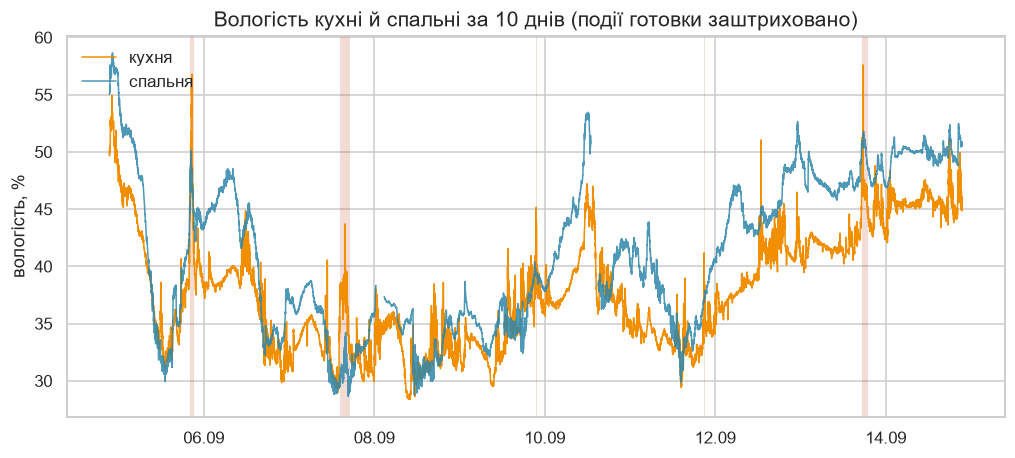

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(minute.index.tz_convert(KYIV), minute["kitchen_hum"],
       color=cleaning.ROOM_COLORS["Kitchen"], lw=1, label="кухня")
ax.plot(minute.index.tz_convert(KYIV), minute["bedroom_hum"],
       color=cleaning.ROOM_COLORS["Bedroom"], lw=1, alpha=0.85, label="спальня")
for _, ev in d_ev.iterrows():
    ax.axvspan(ev.start_utc.tz_convert(KYIV), ev.end_utc.tz_convert(KYIV),
              color="#C73E1D", alpha=0.18, lw=0)
ax.set_title("Вологість кухні й спальні за 10 днів (події готовки заштриховано)")
ax.set_ylabel("вологість, %")
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.legend(loc="upper left", frameon=False)
fig.savefig(IMAGES / "m6_example_week.png", dpi=150, bbox_inches="tight")
plt.show()

Помітні дві довгі яскраво заштриховані ділянки (06.09 ввечері й 08.09
вдень) — це, схоже, тривале приготування (варіння супу, випічка): вологість
кухні йде значно вище спальні на годину-три. Решта чотири події — тонкі
смужки: короткий, різкий, локальний стрибок і швидке повернення назад.
Кухня і спальня в цілому рухаються синхронно (спільна погода), але саме в
моменти подій кухня явно відривається вгору — це і є сигнал готовки.

### Перевірка: це кухня, а не погода?

Для кожної події дивимось, наскільки за той самий проміжок піднялась вологість
у спальні. Якщо кухня росте вдвічі сильніше за спальню — вважаємо стрибок
локальним (готовка), інакше — це радше спільна волога погода.

In [5]:
check = d_ev[["start_utc", "duration_min", "rise_pp", "bedroom_rise_pp", "is_local"]].copy()
check["start_kyiv"] = check.start_utc.dt.tz_convert(KYIV)
check = check[["start_kyiv", "duration_min", "rise_pp", "bedroom_rise_pp", "is_local"]]
check.columns = ["початок (Київ)", "тривалість, хв", "приріст кухні, п.п.",
                "приріст спальні, п.п.", "локальна подія"]
num_cols = ["тривалість, хв", "приріст кухні, п.п.", "приріст спальні, п.п."]
check[num_cols] = check[num_cols].round(1)
check

,початок (Київ),"тривалість, хв","приріст кухні, п.п.","приріст спальні, п.п.",локальна подія
0,2026-09-06 20:14:00+03:00,61.0,18.1,3.7,True
1,2026-09-08 14:19:00+03:00,175.0,13.4,4.4,True
2,2026-09-10 21:36:00+03:00,8.0,8.0,0.3,True
3,2026-09-12 20:52:00+03:00,10.0,8.2,0.4,True
4,2026-09-13 12:50:00+03:00,9.0,11.4,0.4,True
5,2026-09-14 17:15:00+03:00,97.0,14.9,1.1,True


Усі **6 із 6** подій — локальні: кухня в середньому підіймається на
**12.3 п.п.**, спальня в ті самі хвилини — лише на
**1.7 п.п.**. Жодного разу спальня не «підтягнулась»
за кухнею настільки, щоб запідозрити просто вологу погоду — це і є готовка
(або принаймні кухонна активність: чайник, миття посуду гарячою водою).

## 2. Погодинне правило (6 місяців, відтворюване у SQL)

На 6-місячних погодинних даних тієї ж деталізації (1 хв) немає — працюємо
з `kitchen_hum` у `hours_wide.csv`. Правило навмисно просте, щоб один в один
лягти у віконну функцію SQL (`sql/05_cooking.sql`, модуль M8):

```sql
rise = kitchen_hum - AVG(kitchen_hum) OVER (
           ORDER BY ts ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING)
```

тобто приріст поточної години над середнім за **3 попередні години**
(поточна година в середнє не входить). Подія — година з приростом ≥ **Y п.п.**;
сусідні позначені години склеюємо в одну подію (класична задача
gaps-and-islands, як і в M2/M3). Години, де `kitchen_hum` = `NaN` (32 % часу),
**пропускаються, а не заповнюються** — вигадана вологість дала б вигадані події.

In [6]:
y_tbl = []
for Y in (4, 5, 6, 8):
    ev_y = cooking.detect_events_hourly(wide, threshold_pp=Y)
    weeks = (wide.ts.max() - wide.ts.min()).total_seconds() / 3600 / 24 / 7
    y_tbl.append({"поріг Y, п.п.": Y, "подій": len(ev_y),
                 "подій/тиждень": round(len(ev_y) / weeks, 2)})
pd.DataFrame(y_tbl)

,"поріг Y, п.п.",подій,подій/тиждень
0,4,73,2.79
1,5,46,1.76
2,6,26,0.99
3,8,9,0.34


**Обрано Y = 6 п.п.** — узгоджено з X = 8 п.п.: погодинне середнє згладжує
короткий пік готовки (година змішує «до» і «під час»), тому еквівалентний
поріг на годинних даних нижчий за хвилинний. При Y = 6 подій виходить
~1/тиждень — правдоподібно для «іноді готую» і, головне, розподіл по годинах
нижче явно концентрується у вечірні години (не випадковий шум).

## 3. Метрики

Приріст, тривалість і час повернення до норми рахуємо по **точних 1-хвилинних
подіях** (10 днів) — там видно форму події. Розподіл по годинах і днях тижня —
по **погодинних подіях** (6 місяців) — там більше спостережень для статистики.

In [7]:
m = pd.Series(metrics, name="значення").to_frame()
m.index.name = "метрика"
m

,значення
метрика,
threshold_pp_detailed,8.00
threshold_pp_hourly,6.00
baseline_window_min,60.00
hourly_window_h,3.00
n_events_detailed,6.00
events_per_week_detailed,4.20
n_events_hourly,26.00
events_per_week_hourly,0.99
mean_rise_pp,12.34


In [8]:
wd_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Нд"]
h_ev2 = h_ev.copy()
h_ev2["hour_kyiv"] = h_ev2.start_kyiv.dt.hour
h_ev2["weekday_ua"] = h_ev2.start_kyiv.dt.weekday.map(lambda i: wd_names[i])

print("розподіл по годинах доби (погодинні події):")
print(h_ev2.hour_kyiv.value_counts().sort_index().rename("подій").to_frame().T)
print("\nрозподіл по днях тижня (погодинні події):")
print(h_ev2.weekday_ua.value_counts().reindex(wd_names).rename("подій").to_frame().T)

розподіл по годинах доби (погодинні події):
hour_kyiv  0   1   2   4   11  12  13  15  16  17  18  19  20  21  22  23
подій       1   1   1   1   1   1   1   2   2   1   3   3   3   2   2   1

розподіл по днях тижня (погодинні події):
weekday_ua  Пн  Вт  Ср  Чт  Пт  Сб  Нд
подій        5   5   2   6   3   4   1


* На детальних даних — **6 подій за 10 днів**
  (**4.2/тиждень**), середній приріст
  **12.34 п.п.**, середня тривалість
  **60 хв**, після піку вологість повертається
  до норми в середньому за **38 хв**.
* На погодинних даних за 6 місяців — **26 подій**
  (**0.99/тиждень**, менше, бо годинне
  усереднення й Y=6 п.п. — грубіший фільтр, а 32 % годин узагалі без даних).
* Найактивніша година — **19:00 за Києвом**,
  **53.8 %** подій припадає на вечір (17:00–22:59) —
  логічно, це час вечері.

### Коли частіше готують — година доби

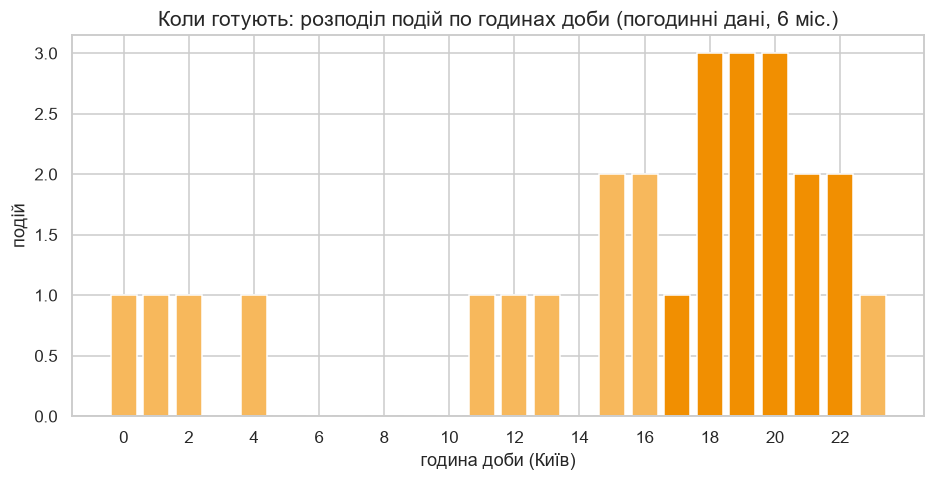

In [9]:
counts_h = (h_ev2.hour_kyiv.value_counts().reindex(range(24), fill_value=0))
colors_h = ["#F18F01" if hh in cooking.EVENING_HOURS else "#F7B85C" for hh in range(24)]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(24), counts_h.values, color=colors_h)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("година доби (Київ)")
ax.set_ylabel("подій")
ax.set_title("Коли готують: розподіл подій по годинах доби (погодинні дані, 6 міс.)")
fig.savefig(IMAGES / "m6_hour_of_day.png", dpi=150, bbox_inches="tight")
plt.show()

Чіткий вечірній пік **18:00–20:00** (по 3 події щогодини) — типовий час
вечері. Ранкових подій майже немає: сніданок, вочевидь, рідко пов'язаний
із варінням/смаженням достатньо довгим, щоб пройти поріг.

### Наскільки сильно росте вологість

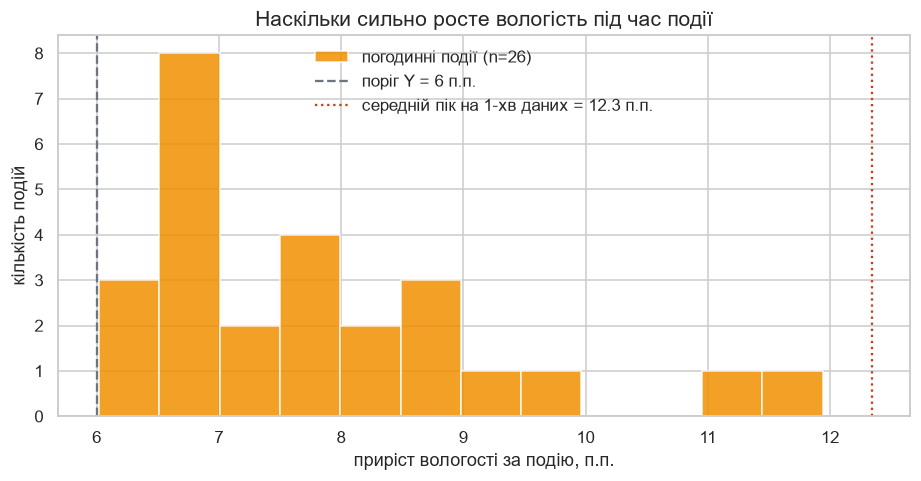

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(h_ev["rise_pp"], bins=12, color=cleaning.ROOM_COLORS["Kitchen"], alpha=0.85,
       label=f"погодинні події (n={len(h_ev)})")
ax.axvline(cooking.THRESHOLD_PP_HOURLY, color="#6C757D", ls="--",
          label=f"поріг Y = {cooking.THRESHOLD_PP_HOURLY:.0f} п.п.")
ax.axvline(d_ev["rise_pp"].mean(), color=cleaning.ROOM_COLORS["Printernya"], ls=":",
          label=f"середній пік на 1-хв даних = {d_ev['rise_pp'].mean():.1f} п.п.")
ax.set_xlabel("приріст вологості за подію, п.п.")
ax.set_ylabel("кількість подій")
ax.set_title("Наскільки сильно росте вологість під час події")
ax.legend(frameon=False)
fig.savefig(IMAGES / "m6_rise_hist.png", dpi=150, bbox_inches="tight")
plt.show()

Більшість погодинних подій — це приріст 6–9 п.п.; кілька виражених
«великих готовок» дають 11–12 п.п. навіть у згладженому годинному середньому.
На 1-хвилинних даних пік у середньому вдвічі вищий (12,3 п.п.) — це очікувано,
бо годинне усереднення розмиває короткий пік вологості по всій годині.

### Скільки подій на тиждень за півроку — і де в цьому винні дірки в даних

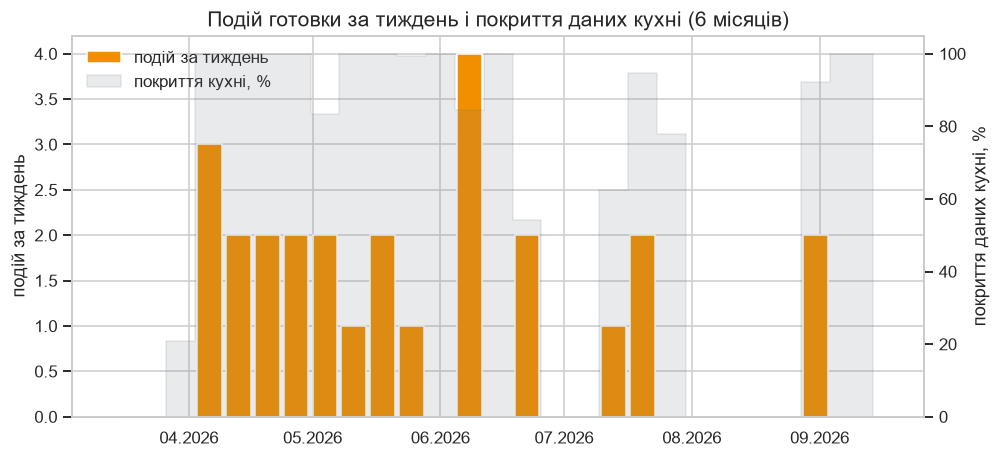

In [11]:
wide_w = wide.copy()
wide_w["week_start"] = (wide_w["ts"] - pd.to_timedelta(wide_w["ts"].dt.dayofweek, unit="D")).dt.normalize()
cov_by_week = wide_w.groupby("week_start")["kitchen_hum"].apply(lambda s: s.notna().mean() * 100)

h_w = h_ev.copy()
h_w["week_start"] = (h_w["start_utc"] - pd.to_timedelta(h_w["start_utc"].dt.dayofweek, unit="D")).dt.normalize()
counts_by_week = h_w.groupby("week_start").size().reindex(cov_by_week.index, fill_value=0)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(counts_by_week.index, counts_by_week.values, width=6,
       color=cleaning.ROOM_COLORS["Kitchen"], label="подій за тиждень")
ax1.set_ylabel("подій за тиждень")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m.%Y"))
ax2 = ax1.twinx()
ax2.fill_between(cov_by_week.index, cov_by_week.values, color="#6C757D", alpha=0.15,
                 step="mid", label="покриття кухні, %")
ax2.set_ylim(0, 105)
ax2.set_ylabel("покриття даних кухні, %")
ax2.grid(False)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc="upper left", frameon=False)
ax1.set_title("Подій готовки за тиждень і покриття даних кухні (6 місяців)")
fig.savefig(IMAGES / "m6_weekly_counts.png", dpi=150, bbox_inches="tight")
plt.show()

Сірою заливкою — покриття кухонного датчика по тижнях. Довгий провал
без жодної помаранчевої смужки (кінець червня — липень) — це не «перестали
готувати», а той самий місячний простій датчика з M1: покриття падає до 0,
і подій там фізично не могло бути виявлено. Там, де покриття близьке до
100 %, події з'являються майже щотижня.

## Висновки

* Поріг **X = 8 п.п.** (1-хв дані, база —
  медіана попередньої години) дає **6 подій за
  10 днів** (4.2/тиждень); при 5 п.п. половина
  «подій» — секундний шум (медіана тривалості 11 хв), при 10 п.п. губляться
  дві явно локальні короткі події.
* Погодинне SQL-правило (Y = 6 п.п., приріст
  над середнім за 3 попередні години) дає **26 подій
  за 6 місяців** (0.99/тиждень) — менше, ніж
  дав би прямий перерахунок частоти з 10-денного вікна, бо годинне
  усереднення й 68 % покриття зрізають частину подій.
* Середній приріст вологості за подію — **12.34 п.п.**
  (медіана 12.43 п.п.), середня тривалість —
  **60 хв**, повернення до норми після піку —
  у середньому **38 хв**.
* Усі 6 детальних подій — **локальні**: кухня росте в середньому на
  12.3 п.п., спальня в ту саму хвилину — лише на
  1.7 п.п. Це відрізняє готовку від просто
  вологої погоди.
* Готують переважно ввечері: пік — **19:00**,
  **53.8 %** подій — у проміжку 17:00–22:59.

## Обмеження

* Покриття кухонної вологості — лише **68 %**
  (датчик місяць мовчав улітку, див. M1). Реальна частота подій за 6 місяців,
  скоріш за все, вища за 0.99/тиждень — просто
  третину часу подію фізично не можна було побачити.
* Метод ловить будь-який **локальний різкий стрибок вологості на кухні**, не
  тільки готовку в буквальному сенсі: чайник, миття посуду гарячою водою,
  сушіння речей теж піднімають вологість і потраплять у ту саму вибірку.
  Тому «події готовки» тут — робоча назва, а не гарантія, що на плиті щось
  смажилось.
* 10-денне вікно детальних даних — це одна конкретна половина вересня;
  сезонність (більше готовки взимку, менше влітку через спеку) на ньому
  побачити не можна, лише на погодинному ряді за 6 місяців.

## Як сказати на співбесіді за 30 секунд

Я побудувала детектор подій готовки з двох незалежних джерел: точні
1-хвилинні дані за 10 днів і грубіші погодинні дані за пів року. Поріг
приросту вологості підбирала не на око, а порівнюючи кілька кандидатів —
5, 8 і 10 відсоткових пунктів — і дивлячись, яка кількість подій і яка їхня
тривалість виглядає правдоподібно, а яка схожа на шум датчика. Щоб
відрізнити готовку від просто вологої погоди, я порівнювала кожен стрибок
вологості на кухні з вологістю в спальні в ту саму хвилину: якщо кухня росте
вдвічі сильніше — це локальна подія. Для довгострокового аналізу написала
окреме, навмисно просте правило на віконних функціях, яке один в один
переноситься в SQL: приріст поточної години над середнім за три попередні.
І я одразу зафіксувала головне обмеження: у кухонного датчика лише 68 %
покриття, тому реальна кількість подій готовки, найімовірніше, вища за ту,
яку я змогла порахувати.